In [134]:
import numpy as np
import numpy.linalg as lg
import io
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
import pandas as pd

# Load edge list
df = pd.read_csv(
    "/content/MMF-Final+Duplicates.csv",
    sep=','
)

print(df.head())
print(df.columns)

   Infection_number        Date Person Infected      Time Infected by  \
0                 1  15/06/2026       Kimberley  15:38:00     Started   
1                 2  16/06/2026          Morgan  10:17:00     Started   
2                 3  16/06/2026           Tayla  11:11:00      Morgan   
3                 4  16/06/2026           Pendo  15:38:00      Mandie   
4                 5  16/06/2026           Haron  15:18:00      Cebile   

   Location  Doctor  
0         1       1  
1         0       1  
2         0       1  
3         1       1  
4         1       0  
Index(['Infection_number', 'Date', 'Person Infected', 'Time', 'Infected by',
       'Location', 'Doctor'],
      dtype='object')


In [136]:
display(df)  # display data

,Infection_number,Date,Person Infected,Time,Infected by,Location,Doctor
0,1,15/06/2026,Kimberley,15:38:00,Started,1,1
1,2,16/06/2026,Morgan,10:17:00,Started,0,1
2,3,16/06/2026,Tayla,11:11:00,Morgan,0,1
3,4,16/06/2026,Pendo,15:38:00,Mandie,1,1
4,5,16/06/2026,Haron,15:18:00,Cebile,1,0
5,6,16/06/2026,Thenuja,08:30:00,Kimberley,1,0
6,7,16/06/2026,Cebile,15:50:00,Tayla,1,1
7,8,16/06/2026,Mandie,10:15:00,Started,0,0
8,9,16/06/2026,Shannon,16:30:00,Tayla,0,0
9,10,16/06/2026,Angelica,15:38:00,Mandie,1,0


**Create Directed graph**

In [161]:
#Create digraph
# Drop rows where 'Infected by' is NaN, as these cannot form valid edges
df_cleaned = df.dropna(subset=['Infected by'])

G = nx.from_pandas_edgelist(
    df_cleaned,
    source="Infected by", # Correct source column
    target="Person Infected", # Correct target column
    create_using=nx.DiGraph()
)

**Network Statistics**

In [162]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

density = nx.density(G)

print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)

Nodes: 35
Edges: 43
Density: 0.03613445378151261


### Density Formula for Directed Graphs

The density of a directed graph (digraph) is given by the formula:

$$\text{Density} = \frac{E}{V \times (V - 1)}$$

Where:
*   $E$ is the number of edges in the graph.
*   $V$ is the number of vertices (nodes) in the graph.

Let's apply this formula to confirm the calculated density:

In graph theory, the density of a graph is a measure of how close it is to being a complete graph (a graph where every possible edge exists). It's the ratio of the number of edges in the graph to the maximum possible number of edges between its nodes. For a directed graph with V nodes, the maximum possible number of edges is V * (V - 1). So, the density is calculated as E / (V * (V - 1)), where E is the actual number of edges.

### Degree Analysis

In a directed graph, each node has an **in-degree** (the number of edges pointing towards it) and an **out-degree** (the number of edges pointing away from it). Let's calculate these for our network.

In [163]:
# Calculate in-degree and out-degree for each node
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Convert to pandas Series for easier handling and display
in_degree_series = pd.Series(in_degree, name='in_degree')
out_degree_series = pd.Series(out_degree, name='out_degree')

# Display the first few in-degrees and out-degrees
print("In-degrees (first 5 nodes):")
display(in_degree_series.head())

print("\nOut-degrees (first 5 nodes):")
display(out_degree_series.head())

In-degrees (first 5 nodes):


,in_degree
Started,0
Kimberley,2
Morgan,1
Tayla,1
Mandie,1



Out-degrees (first 5 nodes):


,out_degree
Started,3
Kimberley,1
Morgan,3
Tayla,2
Mandie,3


### Top and Bottom 5 In-Degrees and Out-Degrees

This shows us which nodes are major recipients of connections (high in-degree) and which are major initiators of connections (high out-degree). Many nodes have no incoming or outgoing connections, indicating they might be isolated or terminal nodes.

In [164]:
# Sort in-degrees and out-degrees
sorted_in_degree = in_degree_series.sort_values(ascending=False)
sorted_out_degree = out_degree_series.sort_values(ascending=False)

print("5 Highest In-Degrees:")
display(sorted_in_degree.head(5))

print("\n5 Lowest In-Degrees:")
display(sorted_in_degree.tail(5))

print("\n5 Highest Out-Degrees:")
display(sorted_out_degree.head(5))

print("\n5 Lowest Out-Degrees:")
display(sorted_out_degree.tail(5))

5 Highest In-Degrees:


,in_degree
Ethel,3
Cebile,2
Kimberley,2
Vix,2
Gebrekiros,2



5 Lowest In-Degrees:


,in_degree
Johanness,1
Tommy,1
Jude,1
Abalo,1
Started,0



5 Highest Out-Degrees:


,out_degree
Boikanyo,5
Ennie,4
Thulisile,4
Thuli,4
Thenuja,3



5 Lowest Out-Degrees:


,out_degree
Johanness,0
Rachid,0
Jude,0
Tommy,0
Abalo,0


### Network Visualization

To get a visual understanding of the network, let's plot the graph. For larger graphs, direct plotting can be cluttered, but it provides a good overview.

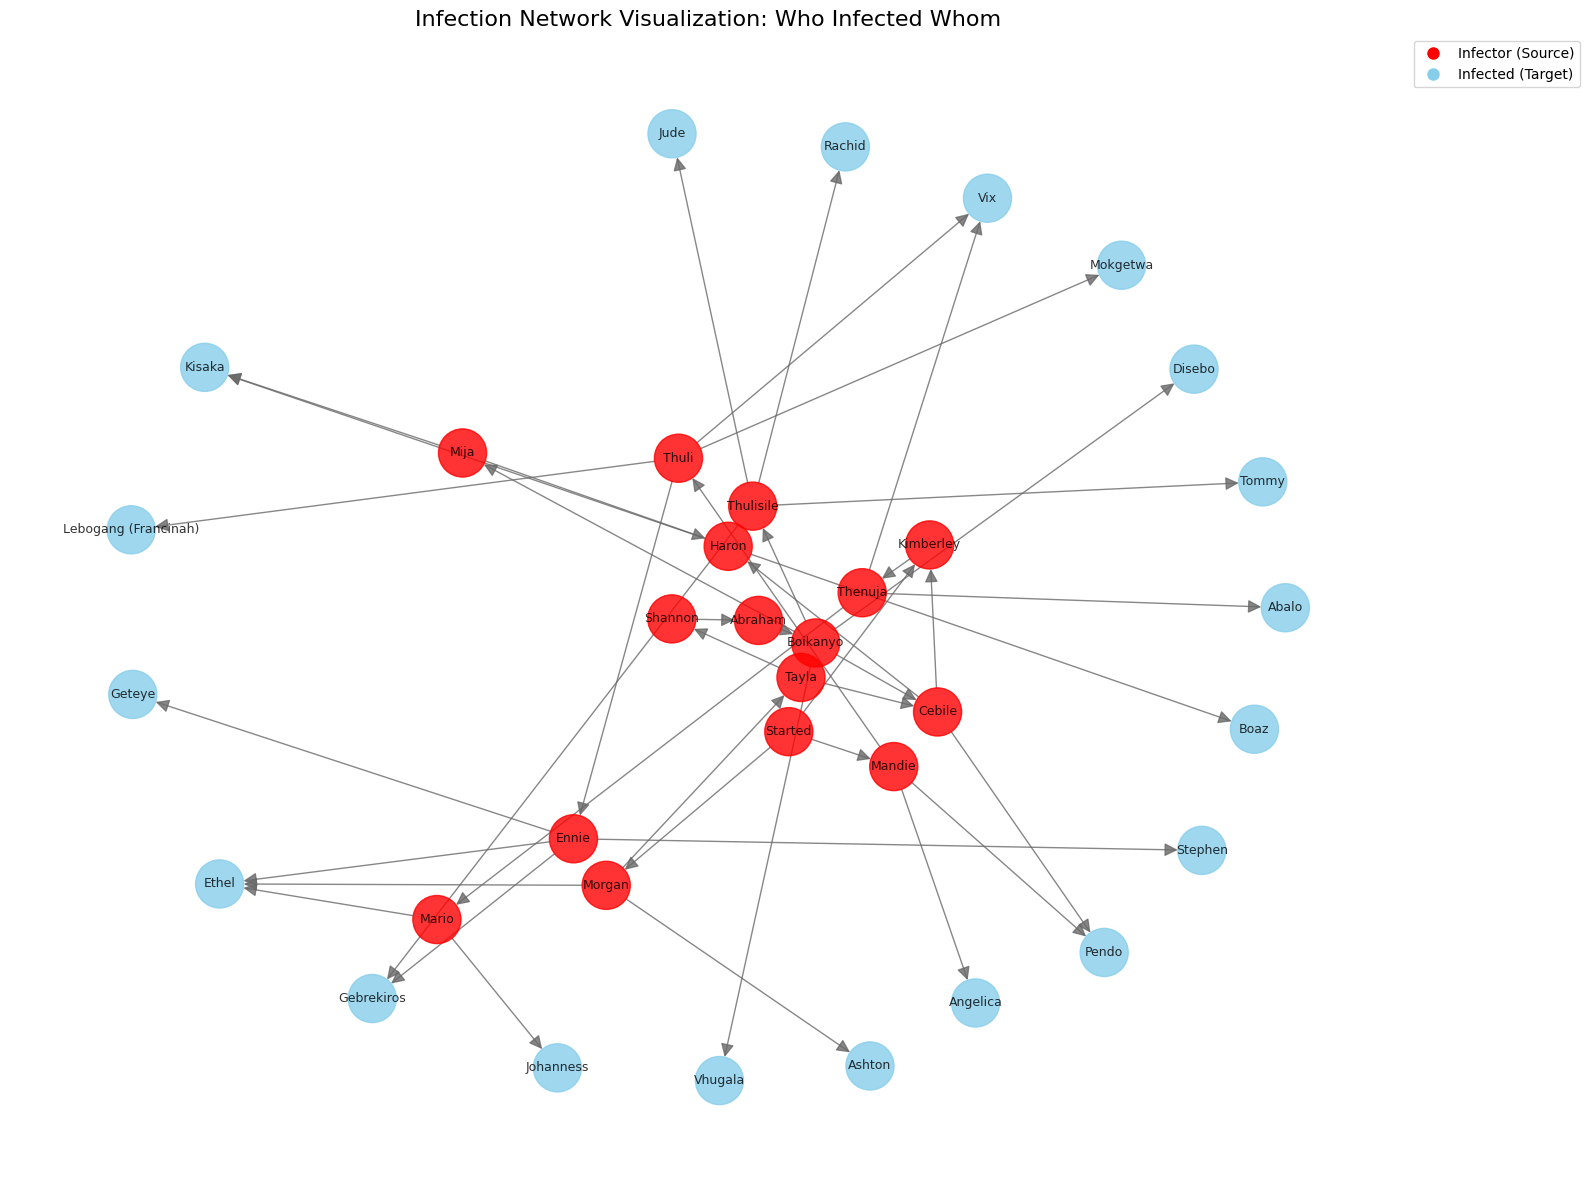

In [166]:
plt.figure(figsize=(16, 12)) # Increase figure size for more space

# Get unique nodes
all_nodes = list(G.nodes())

# Get the list of all nodes that appear as 'Infected by' (sources)
sources = df_cleaned['Infected by'].unique()

# Assign colors based on whether a node is a source or a target.
# A node can be both a source and a target, so we prioritize source color if it's both.
node_colors = []
for node in all_nodes:
    if node in sources:
        node_colors.append('red') # Source nodes (infectors)
    else:
        node_colors.append('skyblue') # Target nodes (infected)

# Use a spring layout for better visualization of node connections
pos = nx.spring_layout(G, k=0.7, iterations=150) # Increased k and iterations to spread out nodes further

nx.draw_networkx(
    G,
    pos=pos,          # Use the defined layout positions
    with_labels=True, # Display node labels (names)
    node_size=1200,   # Increase node size slightly for better visibility of labels
    node_color=node_colors, # Use the defined node colors
    font_size=9,      # Adjust font size for readability
    font_color='black',
    arrowsize=20,     # INCREASE ARROW SIZE SIGNIFICANTLY
    width=1,          # Adjust edge width
    alpha=0.8,        # Adjust transparency
    edge_color='dimgray' # Make edge color darker for better contrast
)

# Create custom legend handles
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Infector (Source)',
                          markerfacecolor='red', markersize=10)
skyblue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Infected (Target)',
                             markerfacecolor='skyblue', markersize=10)
plt.legend(handles=[red_patch, skyblue_patch], loc='upper left', bbox_to_anchor=(1,1))

plt.title('Infection Network Visualization: Who Infected Whom', size=16)
plt.axis('off') # Hide axes for a cleaner look
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### Degree Centrality

Degree centrality is a measure of the number of connections a node has. In a directed graph, we differentiate between **in-degree centrality** (how many incoming connections a node has) and **out-degree centrality** (how many outgoing connections a node has).

In [167]:
# Calculate in-degree centrality
in_degree_centrality = nx.in_degree_centrality(G)

# Calculate out-degree centrality
out_degree_centrality = nx.out_degree_centrality(G)

# Convert to pandas Series for easier handling and display
in_centrality_series = pd.Series(in_degree_centrality, name='in_degree_centrality')
out_centrality_series = pd.Series(out_degree_centrality, name='out_degree_centrality')

print("Top 5 Nodes by In-Degree Centrality:")
display(in_centrality_series.nlargest(5))

print("\nTop 5 Nodes by Out-Degree Centrality:")
display(out_centrality_series.nlargest(5))

Top 5 Nodes by In-Degree Centrality:


,in_degree_centrality
Ethel,0.088235
Kimberley,0.058824
Pendo,0.058824
Cebile,0.058824
Haron,0.058824



Top 5 Nodes by Out-Degree Centrality:


,out_degree_centrality
Boikanyo,0.147059
Thuli,0.117647
Ennie,0.117647
Thulisile,0.117647
Started,0.088235


/tmp/ipykernel_838/2906789816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=in_centrality_series.index, y=in_centrality_series.values, palette='viridis')


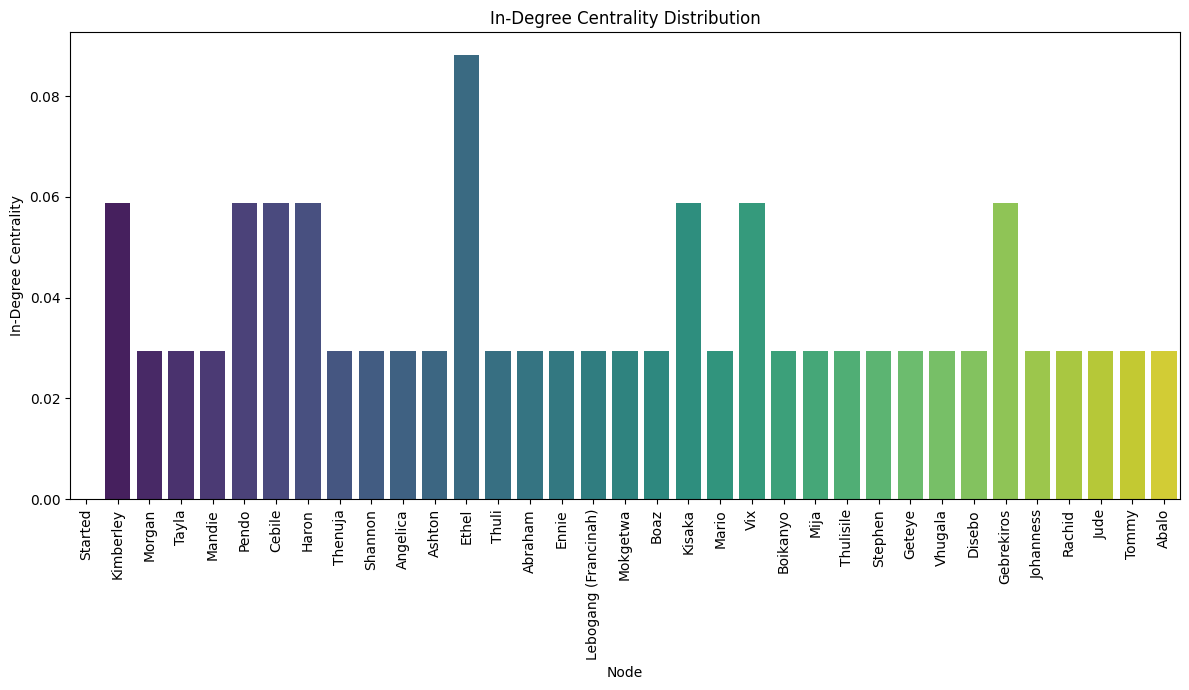

In [143]:
plt.figure(figsize=(12, 7))
sns.barplot(x=in_centrality_series.index, y=in_centrality_series.values, palette='viridis')
plt.title('In-Degree Centrality Distribution')
plt.xlabel('Node')
plt.ylabel('In-Degree Centrality')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Here is the plot for Out-Degree Centrality.

/tmp/ipykernel_838/2330071664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=out_centrality_series.index, y=out_centrality_series.values, palette='magma')


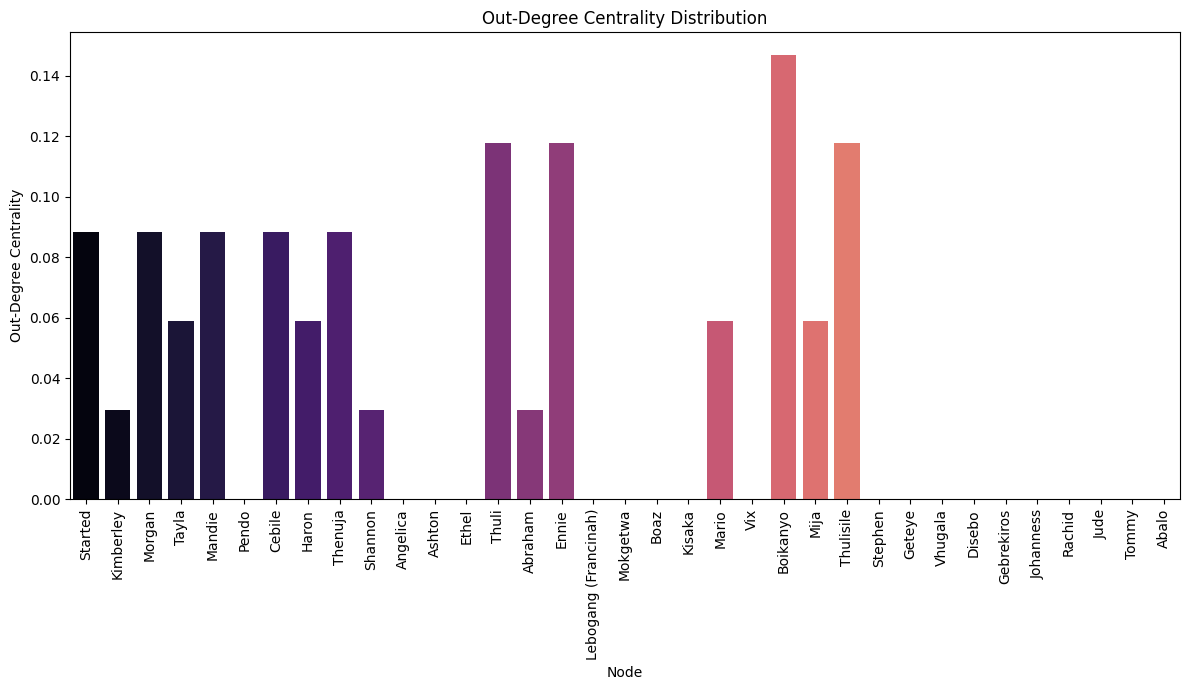

In [144]:
plt.figure(figsize=(12, 7))
sns.barplot(x=out_centrality_series.index, y=out_centrality_series.values, palette='magma')
plt.title('Out-Degree Centrality Distribution')
plt.xlabel('Node')
plt.ylabel('Out-Degree Centrality')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Betweenness Centrality

Betweenness centrality measures the extent to which a node lies on shortest paths between other nodes. Nodes with high betweenness centrality are crucial for communication flow within the network, as they act as 'bridges' or 'gatekeepers'.

In [145]:
# Calculate Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Convert to pandas Series for easier handling and display
betweenness_centrality_series = pd.Series(betweenness_centrality, name='betweenness_centrality')

print("Top 5 Nodes by Betweenness Centrality:")
display(betweenness_centrality_series.nlargest(5))

Top 5 Nodes by Betweenness Centrality:


,betweenness_centrality
Boikanyo,0.056150
Cebile,0.045455
Abraham,0.041889
Kimberley,0.035205
Thenuja,0.033422


Here is the plot for Betweenness Centrality.

/tmp/ipykernel_838/3600988180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=betweenness_centrality_series.index, y=betweenness_centrality_series.values, palette='plasma')


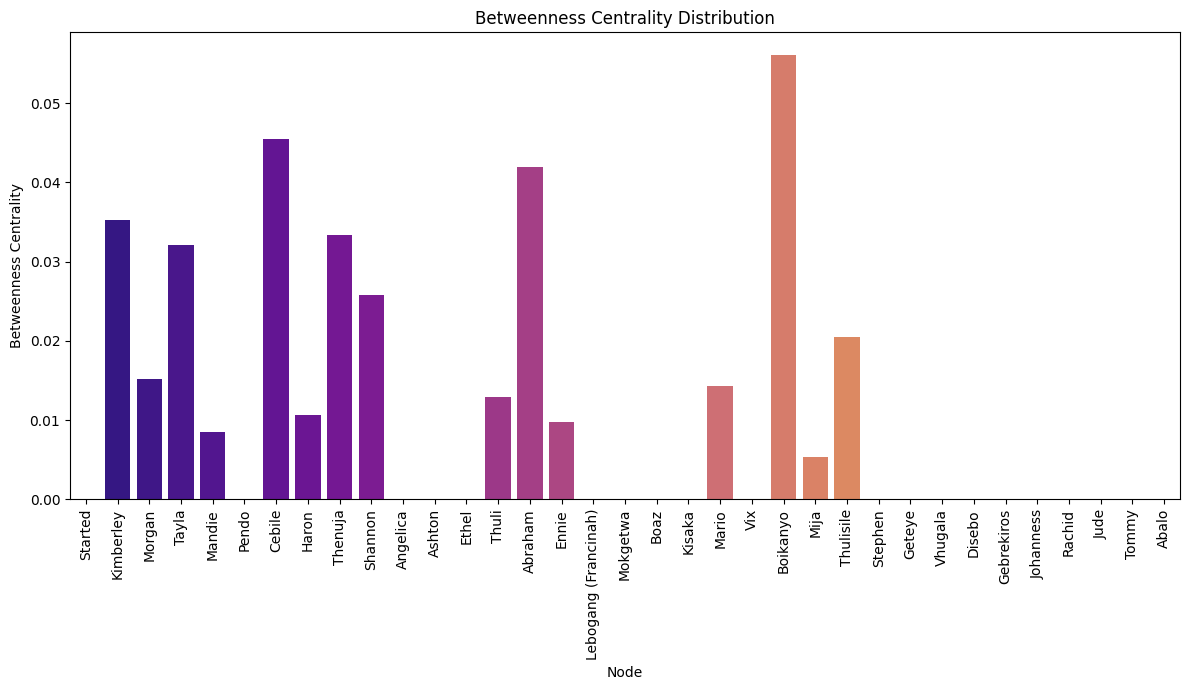

In [146]:
plt.figure(figsize=(12, 7))
sns.barplot(x=betweenness_centrality_series.index, y=betweenness_centrality_series.values, palette='plasma')
plt.title('Betweenness Centrality Distribution')
plt.xlabel('Node')
plt.ylabel('Betweenness Centrality')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Eigenvector Centrality

Eigenvector centrality measures a node's influence based on the centrality of its neighbors. A node with a high eigenvector centrality is connected to other highly central nodes. This can be particularly useful in understanding the most influential nodes in a network beyond just direct connections.

In [147]:
# Calculate Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

# Convert to pandas Series for easier handling and display
eigenvector_centrality_series = pd.Series(eigenvector_centrality, name='eigenvector_centrality')

print("Top 5 Nodes by Eigenvector Centrality:")
display(eigenvector_centrality_series.nlargest(5))

Top 5 Nodes by Eigenvector Centrality:


,eigenvector_centrality
Ethel,0.707024
Johanness,0.707024
Vix,0.008849
Mario,0.008849
Abalo,0.008849


Here is the plot for Eigenvector Centrality.

/tmp/ipykernel_838/1014510478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eigenvector_centrality_series.index, y=eigenvector_centrality_series.values, palette='cividis')


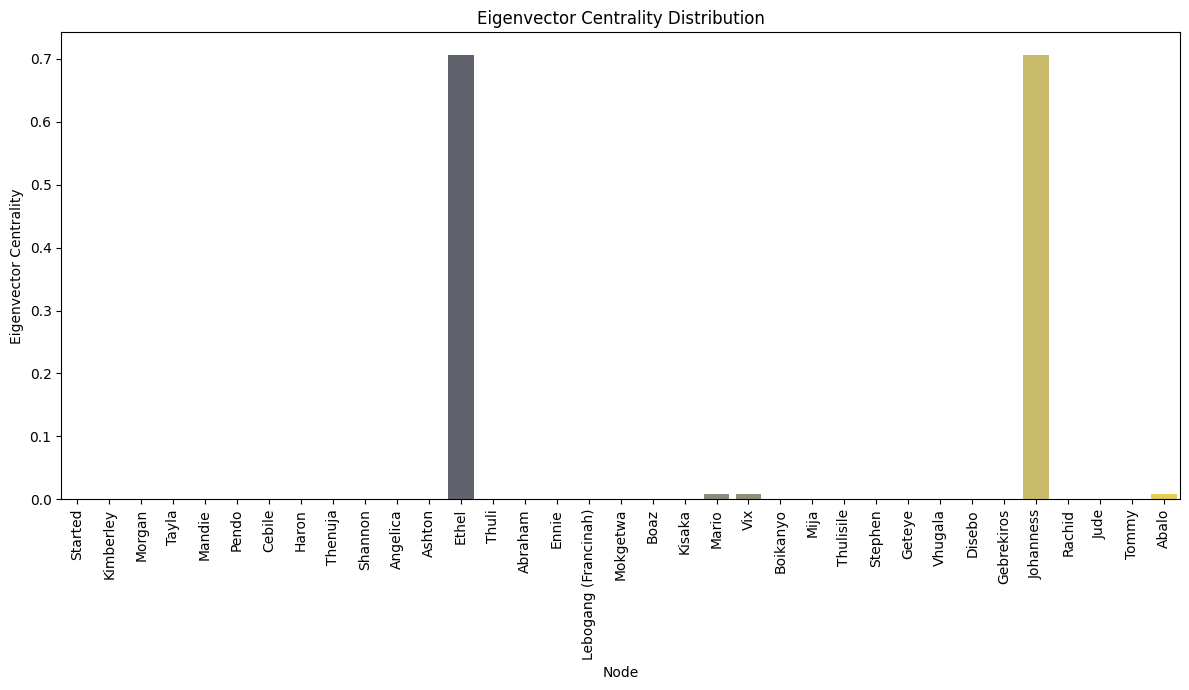

In [148]:
plt.figure(figsize=(12, 7))
sns.barplot(x=eigenvector_centrality_series.index, y=eigenvector_centrality_series.values, palette='cividis')
plt.title('Eigenvector Centrality Distribution')
plt.xlabel('Node')
plt.ylabel('Eigenvector Centrality')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Network Visualization by In-Degree Centrality

Here, nodes are colored based on their In-Degree Centrality. Darker colors indicate higher in-degree centrality, meaning the node is infected by more other nodes.

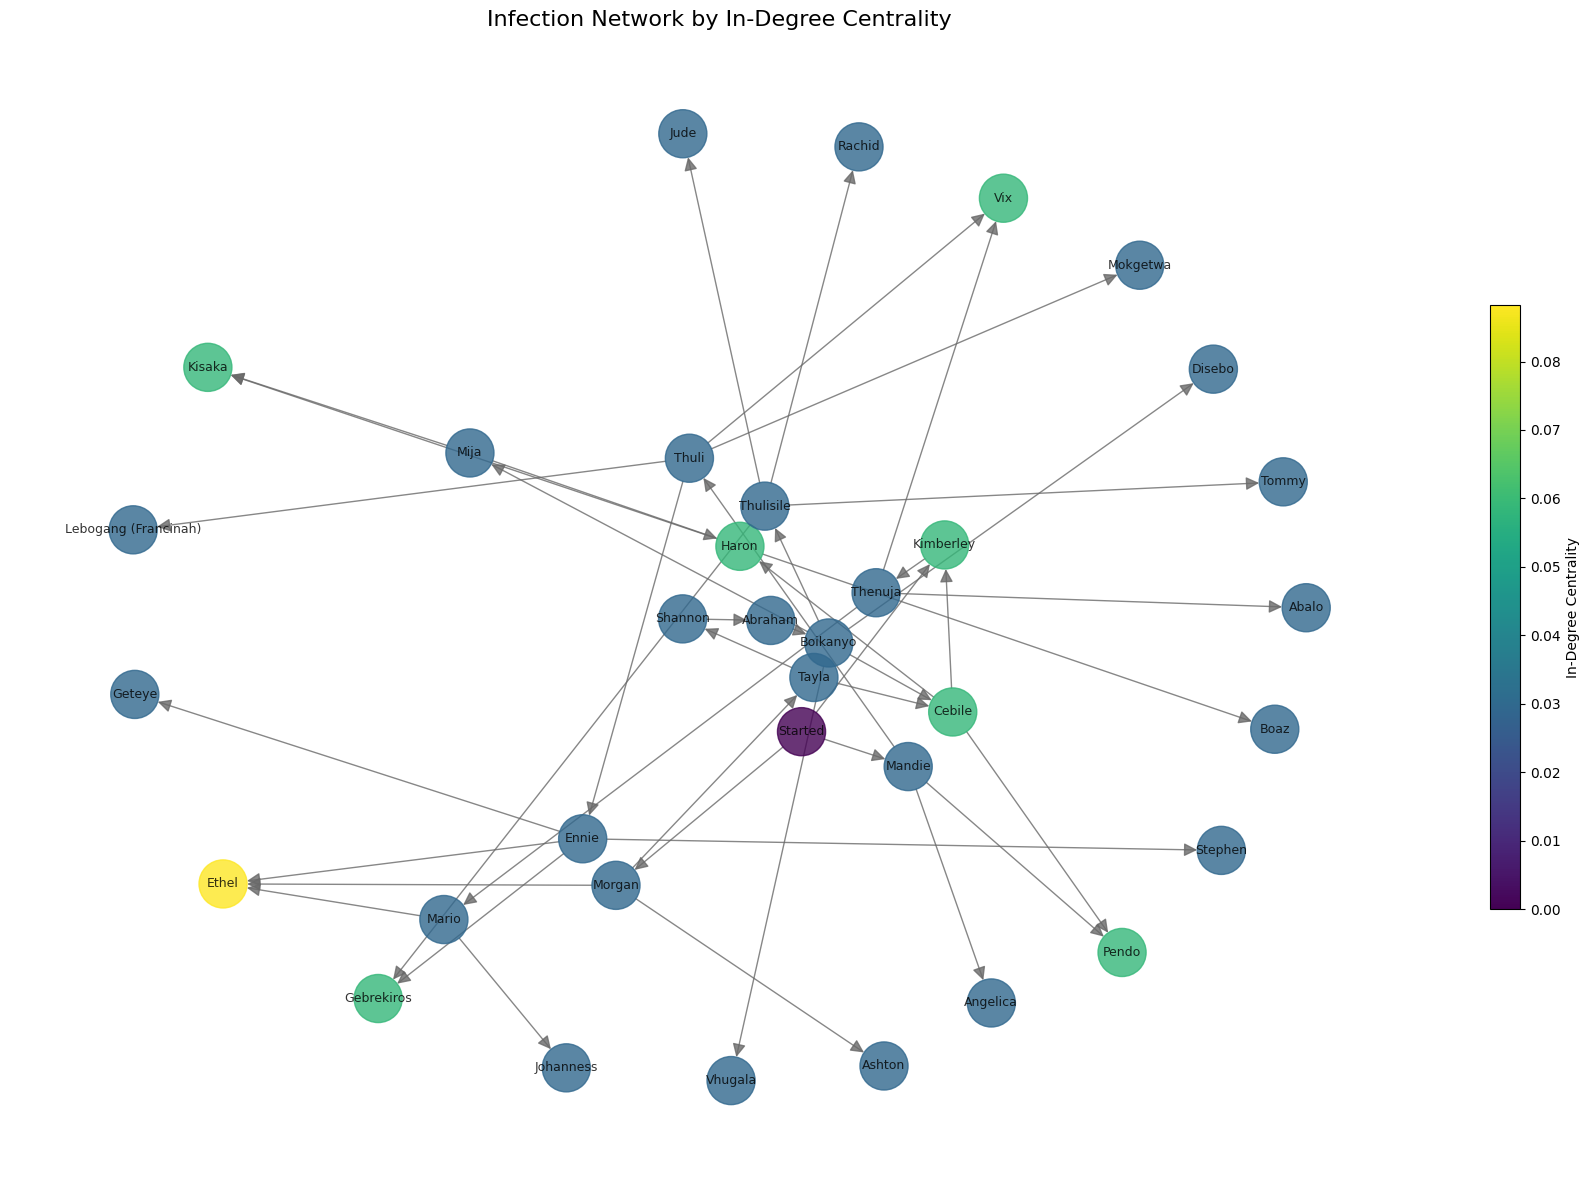

In [168]:
# Normalize in-degree centrality for coloring
node_in_centrality = [in_centrality_series.loc[node] for node in G.nodes()]
norm = plt.Normalize(vmin=min(node_in_centrality), vmax=max(node_in_centrality))
cmap = plt.cm.viridis

plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    node_color=[cmap(norm(val)) for val in node_in_centrality],
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(node_in_centrality)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('In-Degree Centrality')

plt.title('Infection Network by In-Degree Centrality', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Network Visualization by Out-Degree Centrality

Nodes are colored based on their Out-Degree Centrality. Darker colors indicate higher out-degree centrality, meaning the node infects more other nodes.

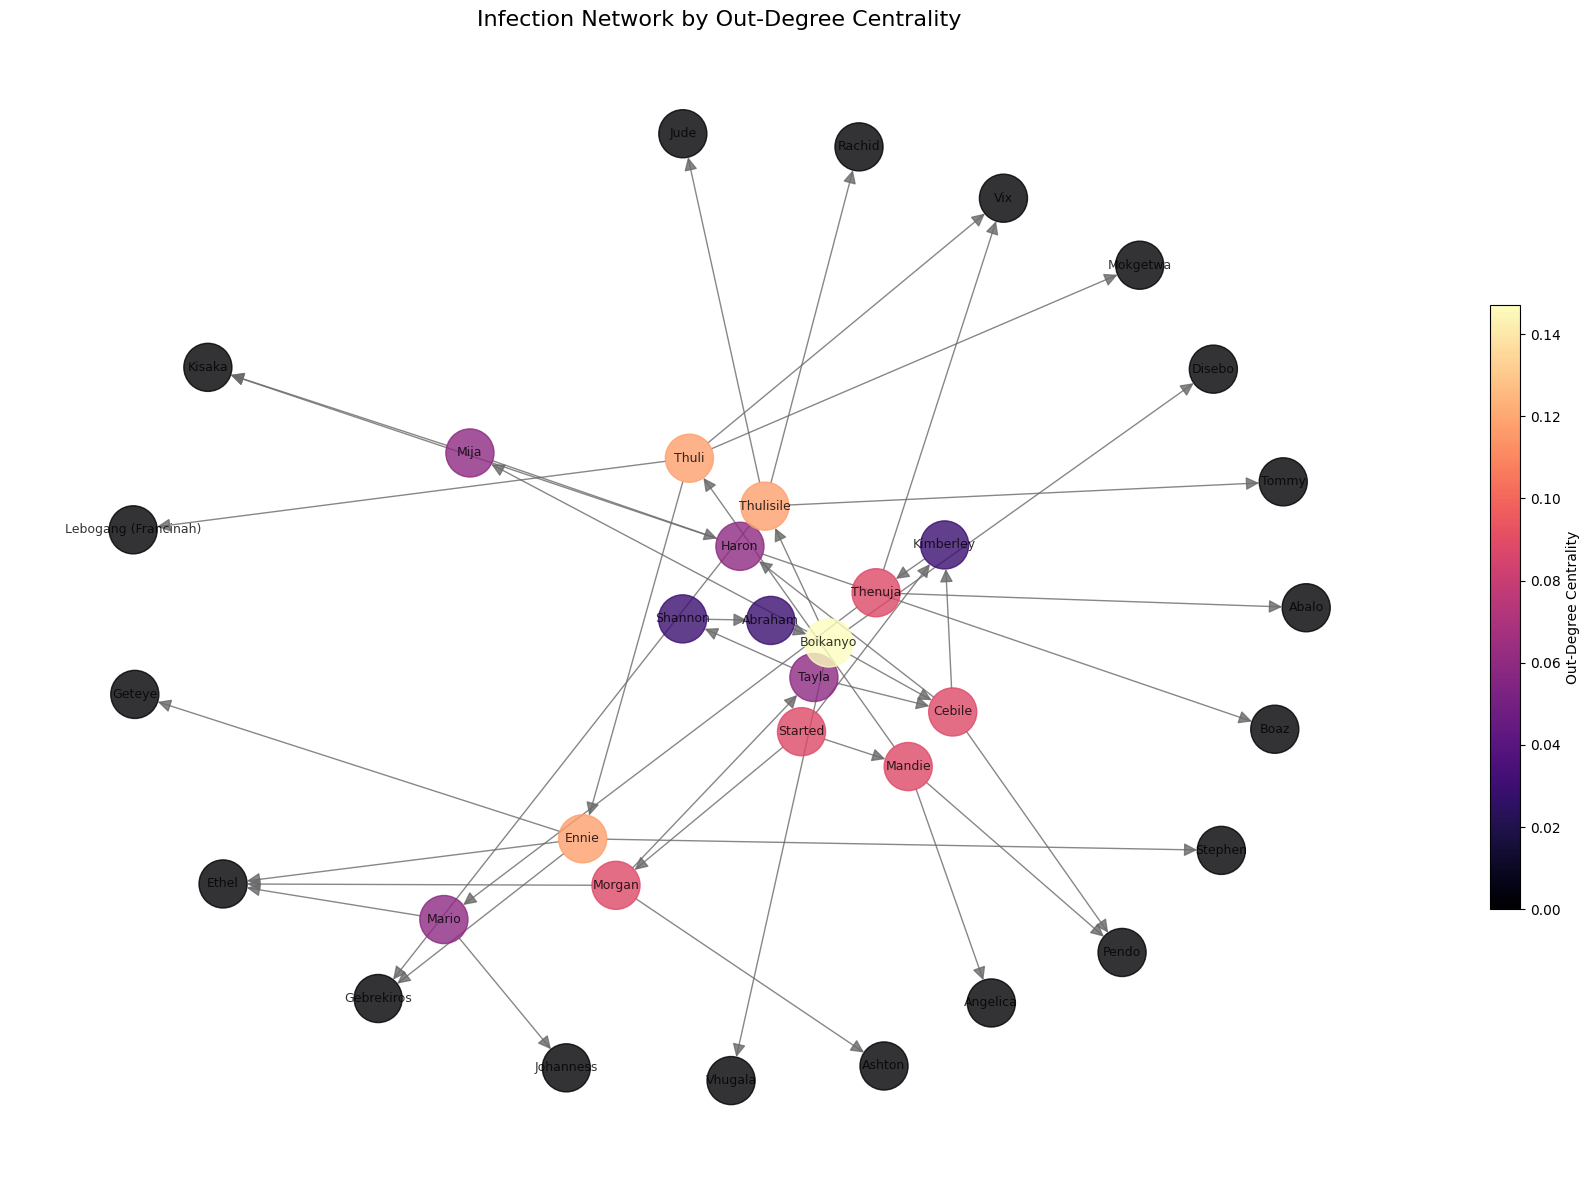

In [169]:
# Normalize out-degree centrality for coloring
node_out_centrality = [out_centrality_series.loc[node] for node in G.nodes()]
norm = plt.Normalize(vmin=min(node_out_centrality), vmax=max(node_out_centrality))
cmap = plt.cm.magma

plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    node_color=[cmap(norm(val)) for val in node_out_centrality],
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(node_out_centrality)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Out-Degree Centrality')

plt.title('Infection Network by Out-Degree Centrality', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Network Visualization by Betweenness Centrality

Nodes are colored based on their Betweenness Centrality. Darker colors indicate higher betweenness centrality, meaning the node lies on more shortest paths between other nodes.

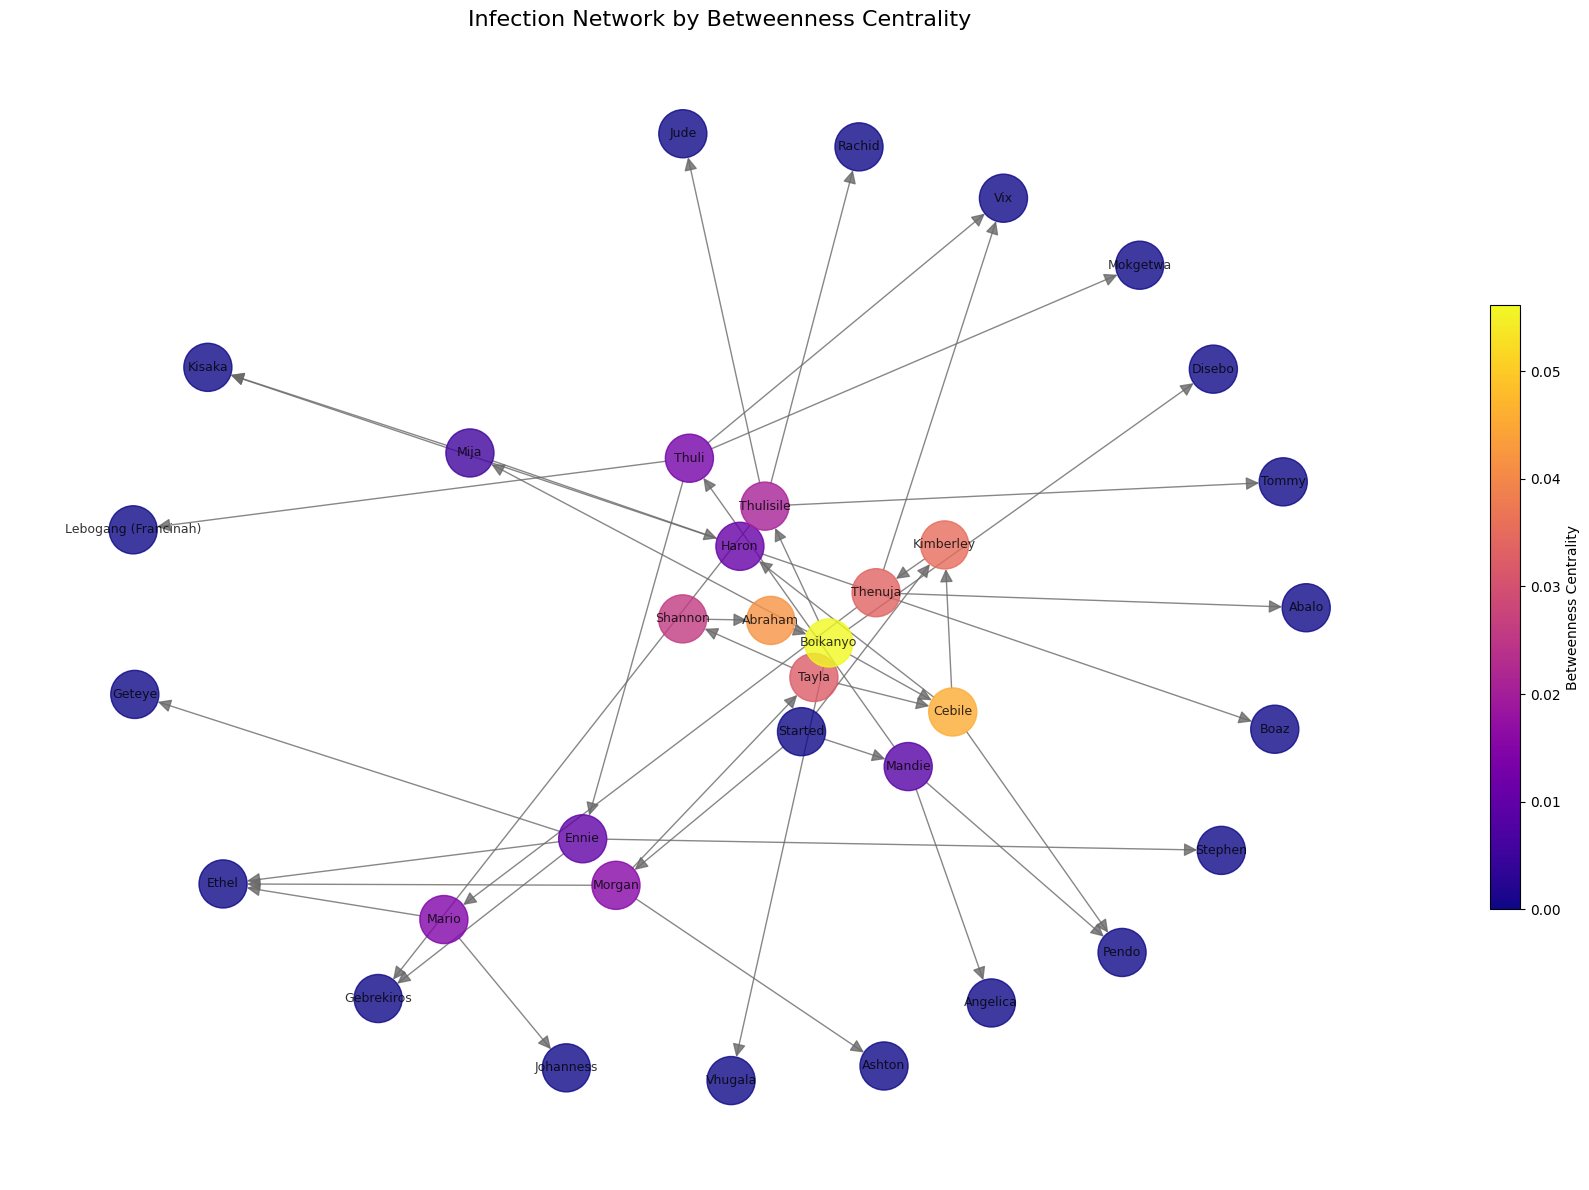

In [170]:
# Normalize betweenness centrality for coloring
node_betweenness_centrality = [betweenness_centrality_series.loc[node] for node in G.nodes()]
norm = plt.Normalize(vmin=min(node_betweenness_centrality), vmax=max(node_betweenness_centrality))
cmap = plt.cm.plasma

plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    node_color=[cmap(norm(val)) for val in node_betweenness_centrality],
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(node_betweenness_centrality)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Betweenness Centrality')

plt.title('Infection Network by Betweenness Centrality', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Network Visualization by Eigenvector Centrality

Nodes are colored based on their Eigenvector Centrality. Darker colors indicate higher eigenvector centrality, meaning the node is connected to other highly influential nodes. Remove the betweenness node what result will that lead too, which lead to no spillover effects as Boikanyo will not be there so transfer the MMF

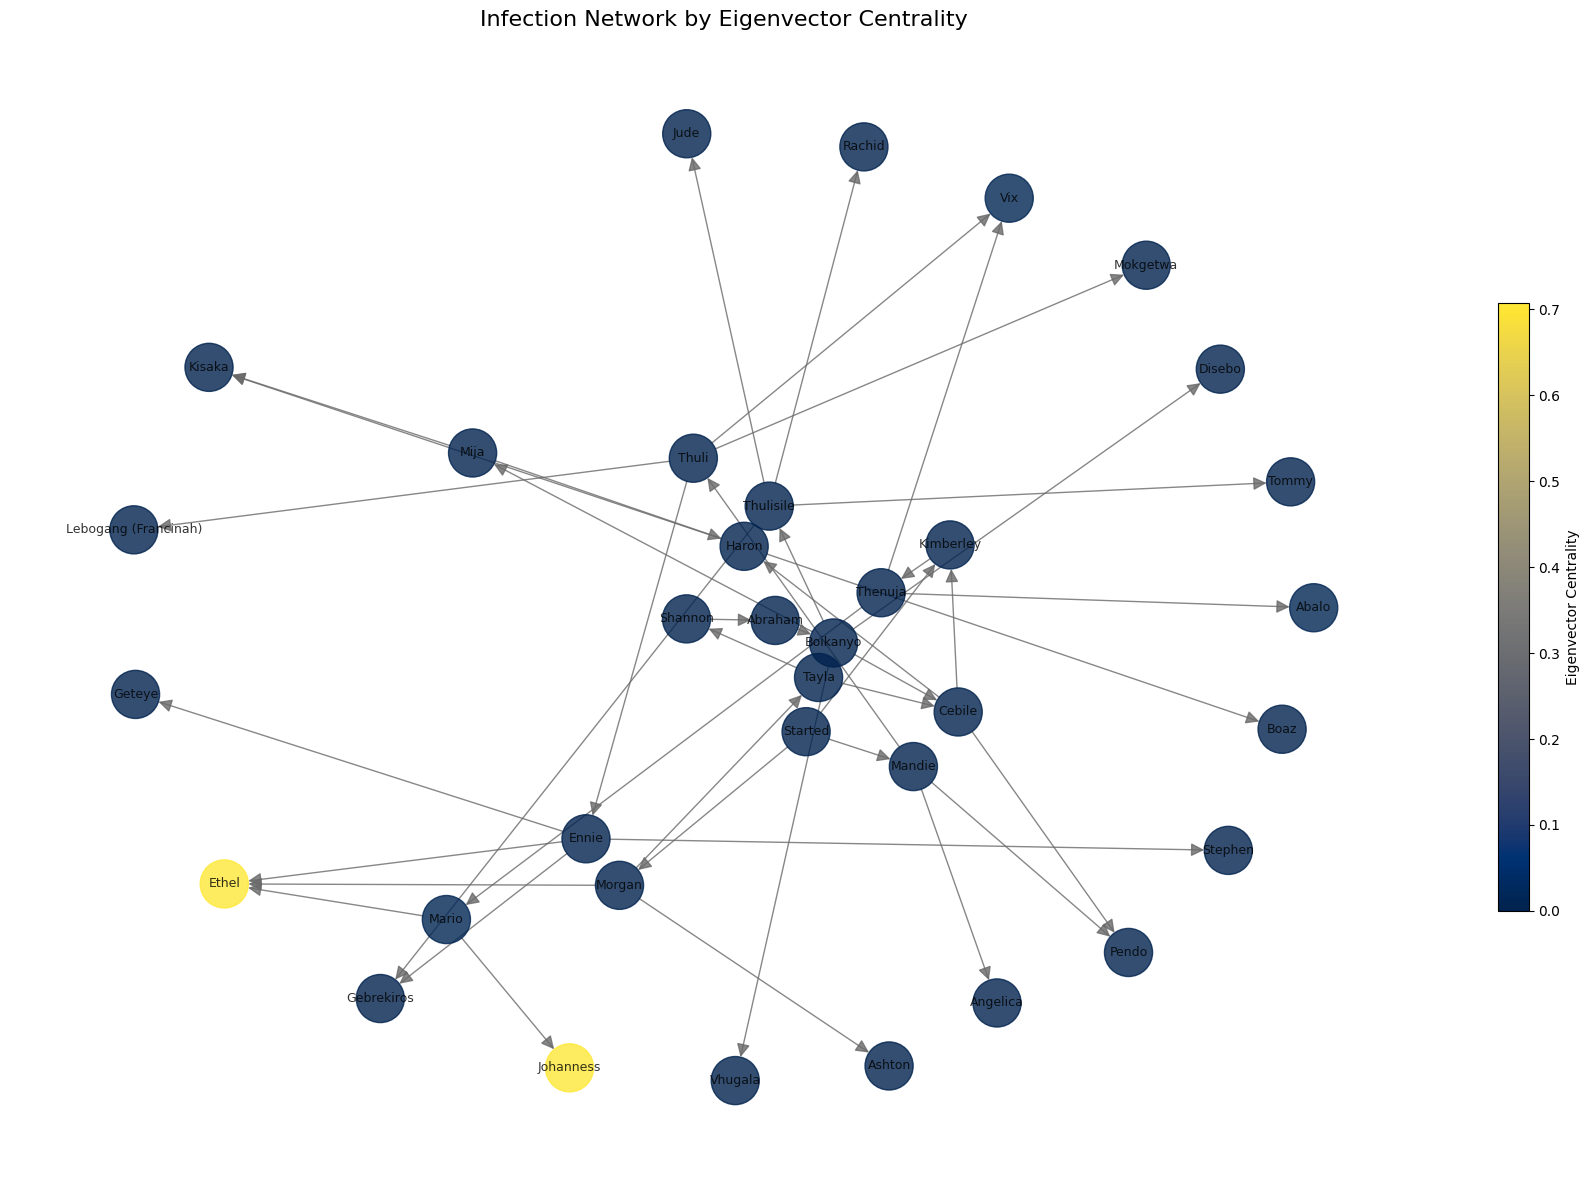

In [171]:
# Normalize eigenvector centrality for coloring
node_eigenvector_centrality = [eigenvector_centrality_series.loc[node] for node in G.nodes()]
norm = plt.Normalize(vmin=min(node_eigenvector_centrality), vmax=max(node_eigenvector_centrality))
cmap = plt.cm.cividis

plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=1200,
    node_color=[cmap(norm(val)) for val in node_eigenvector_centrality],
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(node_eigenvector_centrality)
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Eigenvector Centrality')

plt.title('Infection Network by Eigenvector Centrality', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Simulating Node Removal: Impact of Removing a High Betweenness Centrality Node (Boikanyo)

Let's investigate the impact of removing a node that has high betweenness centrality. We will remove 'Boikanyo' from the network, as it appears to have a significant betweenness centrality from our previous analysis. Then we will re-examine the network structure and centrality measures.

Node 'Boikanyo' removed from the graph.

Top 5 Nodes by Betweenness Centrality after removing 'Boikanyo':


,betweenness_centrality_removed
Cebile,0.022727
Thenuja,0.021307
Kimberley,0.020360
Tayla,0.017992
Thuli,0.013731


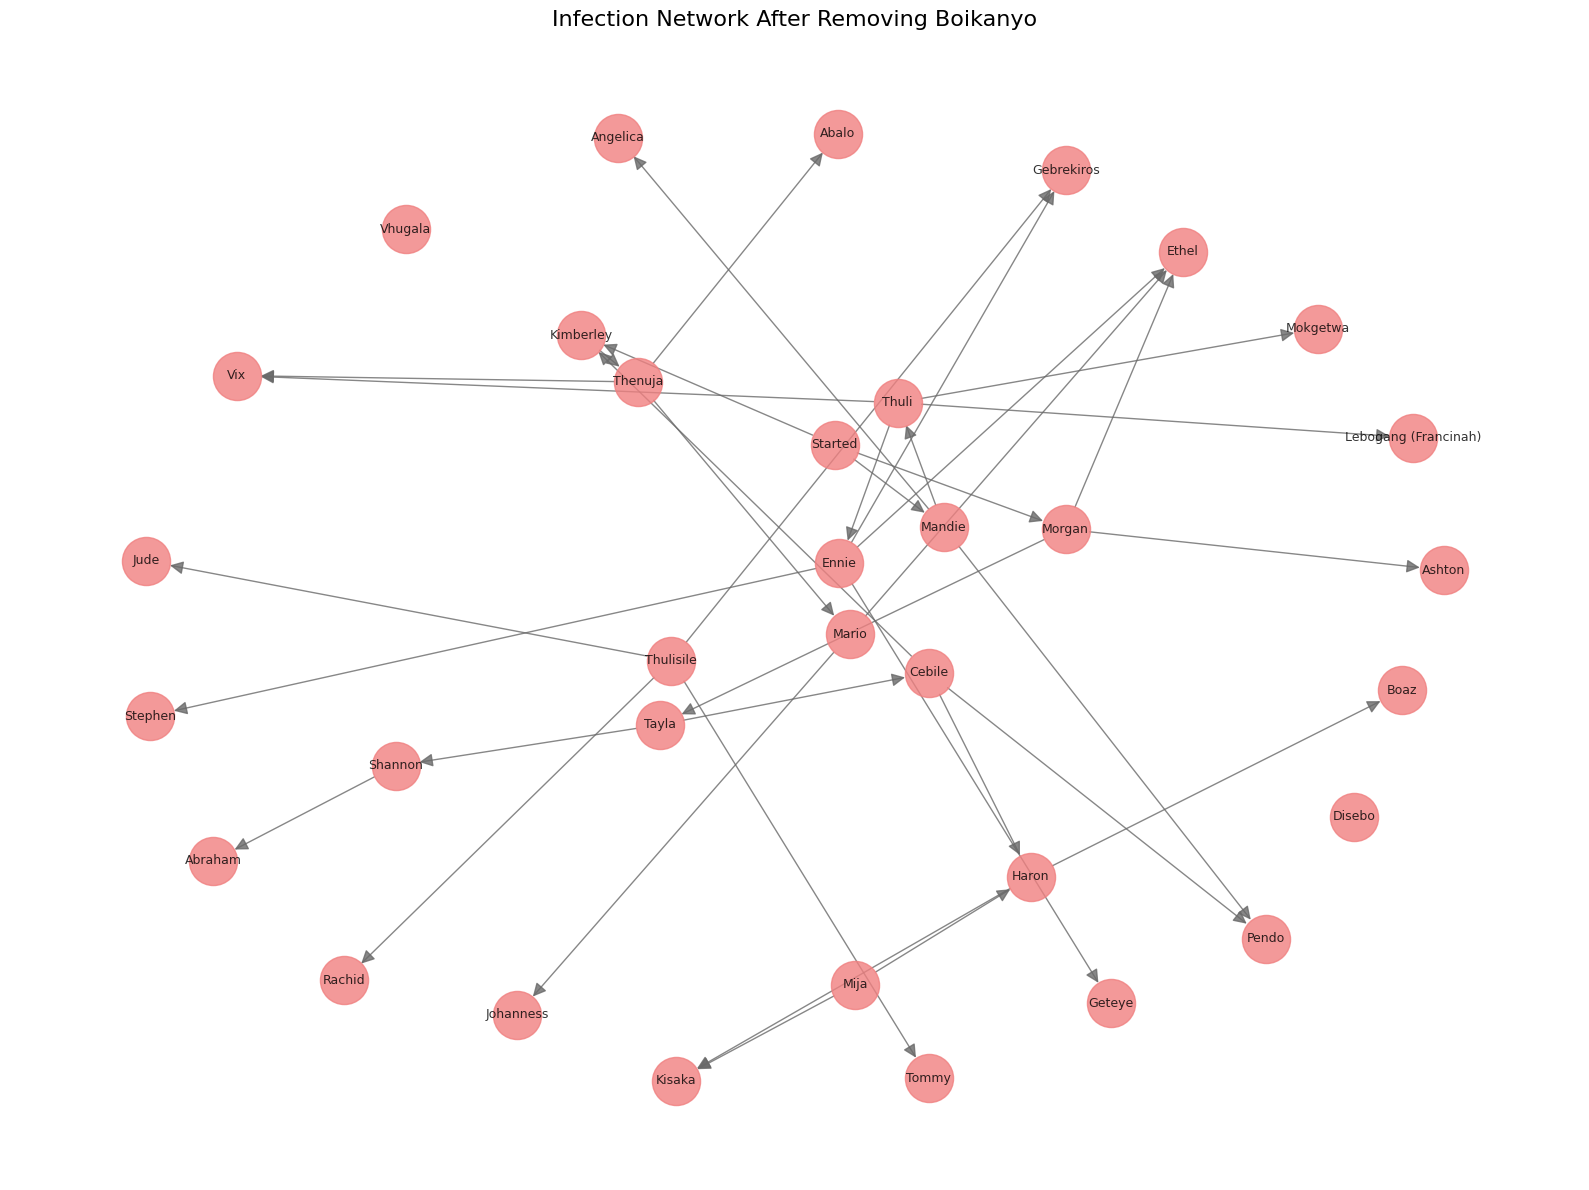

In [172]:
# Create a copy of the original graph to simulate node removal
G_removed_boikanyo = G.copy()

# Remove 'Boikanyo' node if it exists
if 'Boikanyo' in G_removed_boikanyo.nodes():
    G_removed_boikanyo.remove_node('Boikanyo')
    print("Node 'Boikanyo' removed from the graph.")
else:
    print("Node 'Boikanyo' not found in the graph.")

# Recalculate Betweenness Centrality for the modified graph
betweenness_centrality_removed = nx.betweenness_centrality(G_removed_boikanyo)
betweenness_centrality_removed_series = pd.Series(betweenness_centrality_removed, name='betweenness_centrality_removed')

print("\nTop 5 Nodes by Betweenness Centrality after removing 'Boikanyo':")
display(betweenness_centrality_removed_series.nlargest(5))

# Visualize the graph after removing 'Boikanyo'
plt.figure(figsize=(16, 12))

# We'll need to recompute positions for the new graph or use a subset of the old positions
# For simplicity and to show the effect, we'll recompute the layout.
# If we wanted to preserve relative positions, we'd adjust 'pos' directly.
pos_removed_boikanyo = nx.spring_layout(G_removed_boikanyo, k=0.7, iterations=150)

nx.draw_networkx(
    G_removed_boikanyo,
    pos=pos_removed_boikanyo,
    with_labels=True,
    node_size=1200,
    node_color='lightcoral', # Color all remaining nodes uniformly for this initial visualization
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

plt.title('Infection Network After Removing Boikanyo', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Analysis of 'Boikanyo' Removal

By removing 'Boikanyo', a node with high betweenness centrality, we can observe how the network's structure and the flow of information (or in this case, infection) are affected. Such a node often acts as a critical link between different parts of the network. Its removal can:

*   **Disrupt flow:** Paths that previously went through 'Boikanyo' are now broken, potentially increasing the distance between other nodes or isolating parts of the network.
*   **Redistribute centrality:** Other nodes might see an increase in their betweenness centrality if they now lie on new shortest paths.
*   **Reduce connectivity:** The overall connectivity of the network might decrease, leading to a fragmented network where some nodes can no longer reach others.

Let's now consider removing a highly central node for other centrality measures.

### Simulating Node Removal: Impact of Removing a High In-Degree Centrality Node

Next, let's examine what happens when we remove a node that has a high In-Degree Centrality. This kind of node is frequently infected by others. Removing it might reduce the overall 'infection load' or change the pattern of infection reception in the network.

Node with highest In-Degree Centrality: Ethel
Node 'Ethel' removed from the graph.

Top 5 Nodes by In-Degree Centrality after removing 'Ethel':


,in_centrality_removed
Kimberley,0.060606
Pendo,0.060606
Cebile,0.060606
Haron,0.060606
Kisaka,0.060606


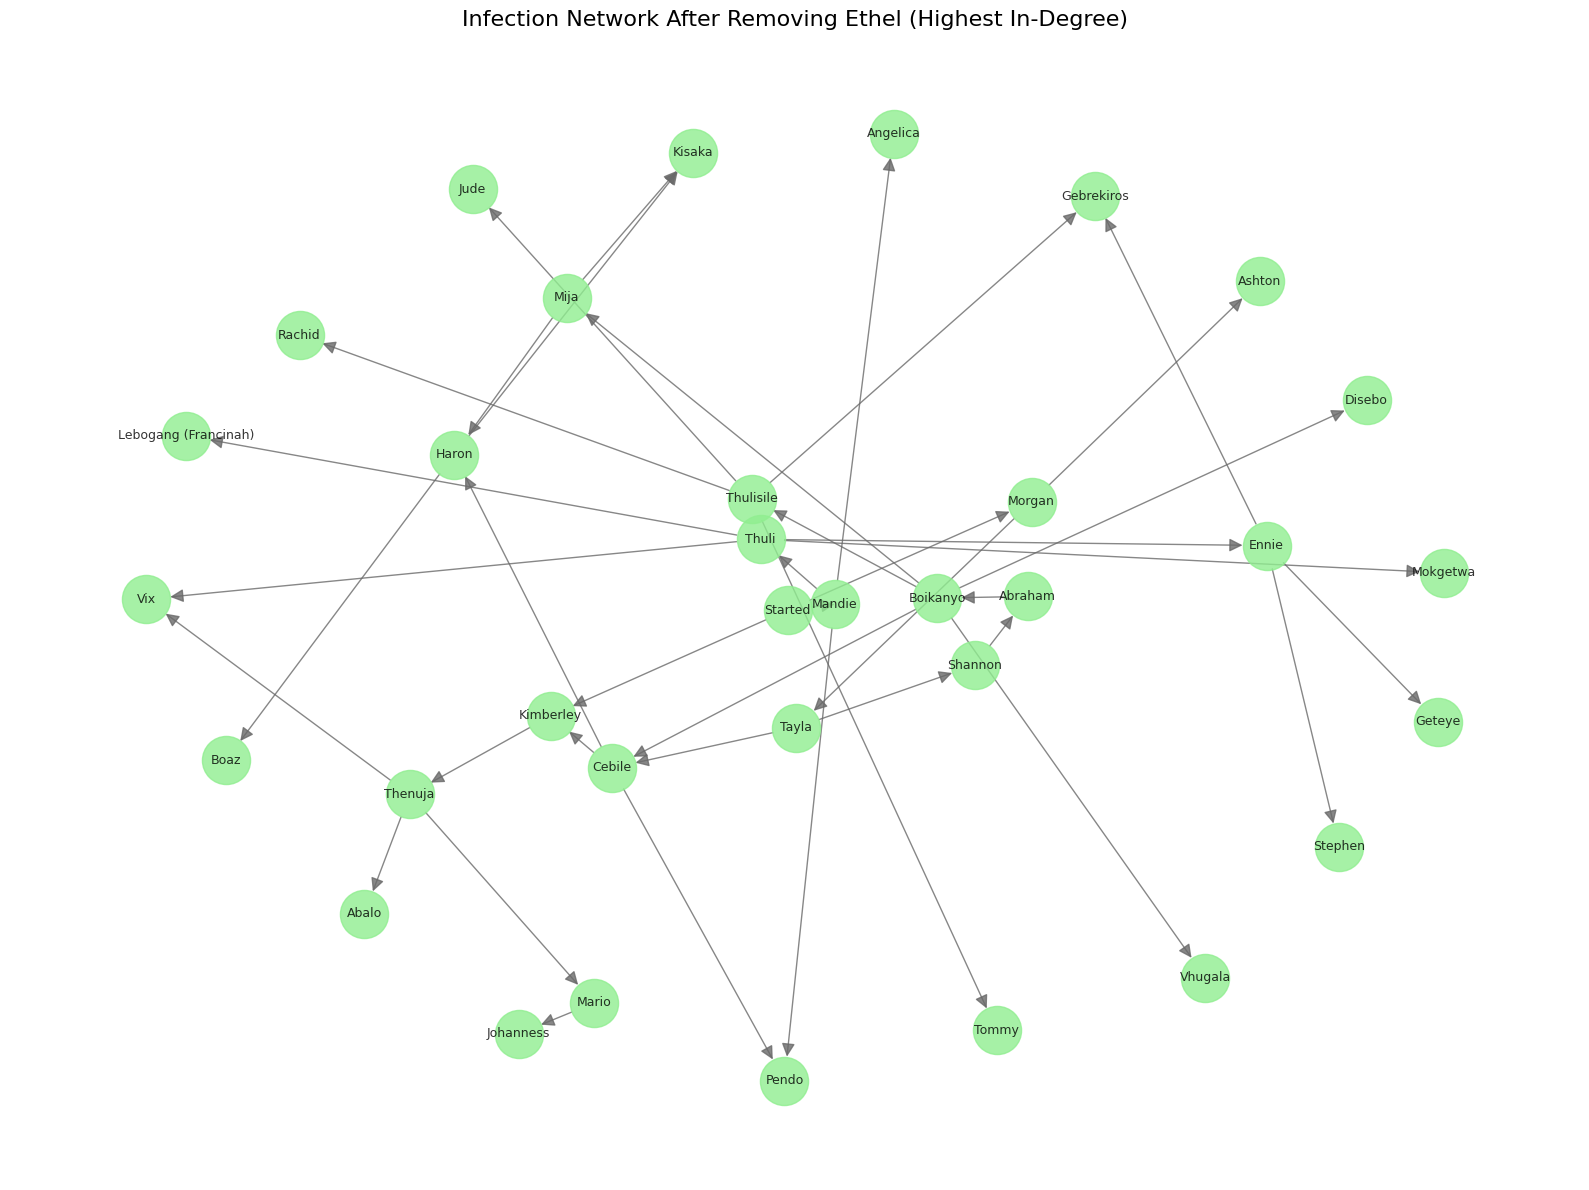

In [173]:
# Identify the node with the highest In-Degree Centrality in the original graph
top_in_degree_node = in_centrality_series.idxmax()
print(f"Node with highest In-Degree Centrality: {top_in_degree_node}")

# Create a copy of the original graph to simulate node removal
G_removed_in_degree = G.copy()

# Remove the top in-degree node if it exists
if top_in_degree_node in G_removed_in_degree.nodes():
    G_removed_in_degree.remove_node(top_in_degree_node)
    print(f"Node '{top_in_degree_node}' removed from the graph.")
else:
    print(f"Node '{top_in_degree_node}' not found in the graph.")

# Recalculate In-Degree Centrality for the modified graph
in_degree_centrality_removed = nx.in_degree_centrality(G_removed_in_degree)
in_centrality_removed_series = pd.Series(in_degree_centrality_removed, name='in_centrality_removed')

print(f"\nTop 5 Nodes by In-Degree Centrality after removing '{top_in_degree_node}':")
display(in_centrality_removed_series.nlargest(5))

# Visualize the graph after removing the top in-degree node
plt.figure(figsize=(16, 12))

pos_removed_in_degree = nx.spring_layout(G_removed_in_degree, k=0.7, iterations=150)

nx.draw_networkx(
    G_removed_in_degree,
    pos=pos_removed_in_degree,
    with_labels=True,
    node_size=1200,
    node_color='lightgreen', # Color all remaining nodes uniformly for this initial visualization
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

plt.title(f'Infection Network After Removing {top_in_degree_node} (Highest In-Degree)', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Simulating Node Removal: Impact of Removing a High Out-Degree Centrality Node

Now, let's investigate the impact of removing a node that has a high Out-Degree Centrality. This kind of node is a major initiator of infections. Removing it might significantly reduce the spread of infection or alter the overall infection pathways.

Node with highest Out-Degree Centrality: Boikanyo
Node 'Boikanyo' removed from the graph.

Top 5 Nodes by Out-Degree Centrality after removing 'Boikanyo':


,out_centrality_removed
Thuli,0.121212
Ennie,0.121212
Thulisile,0.121212
Started,0.090909
Morgan,0.090909


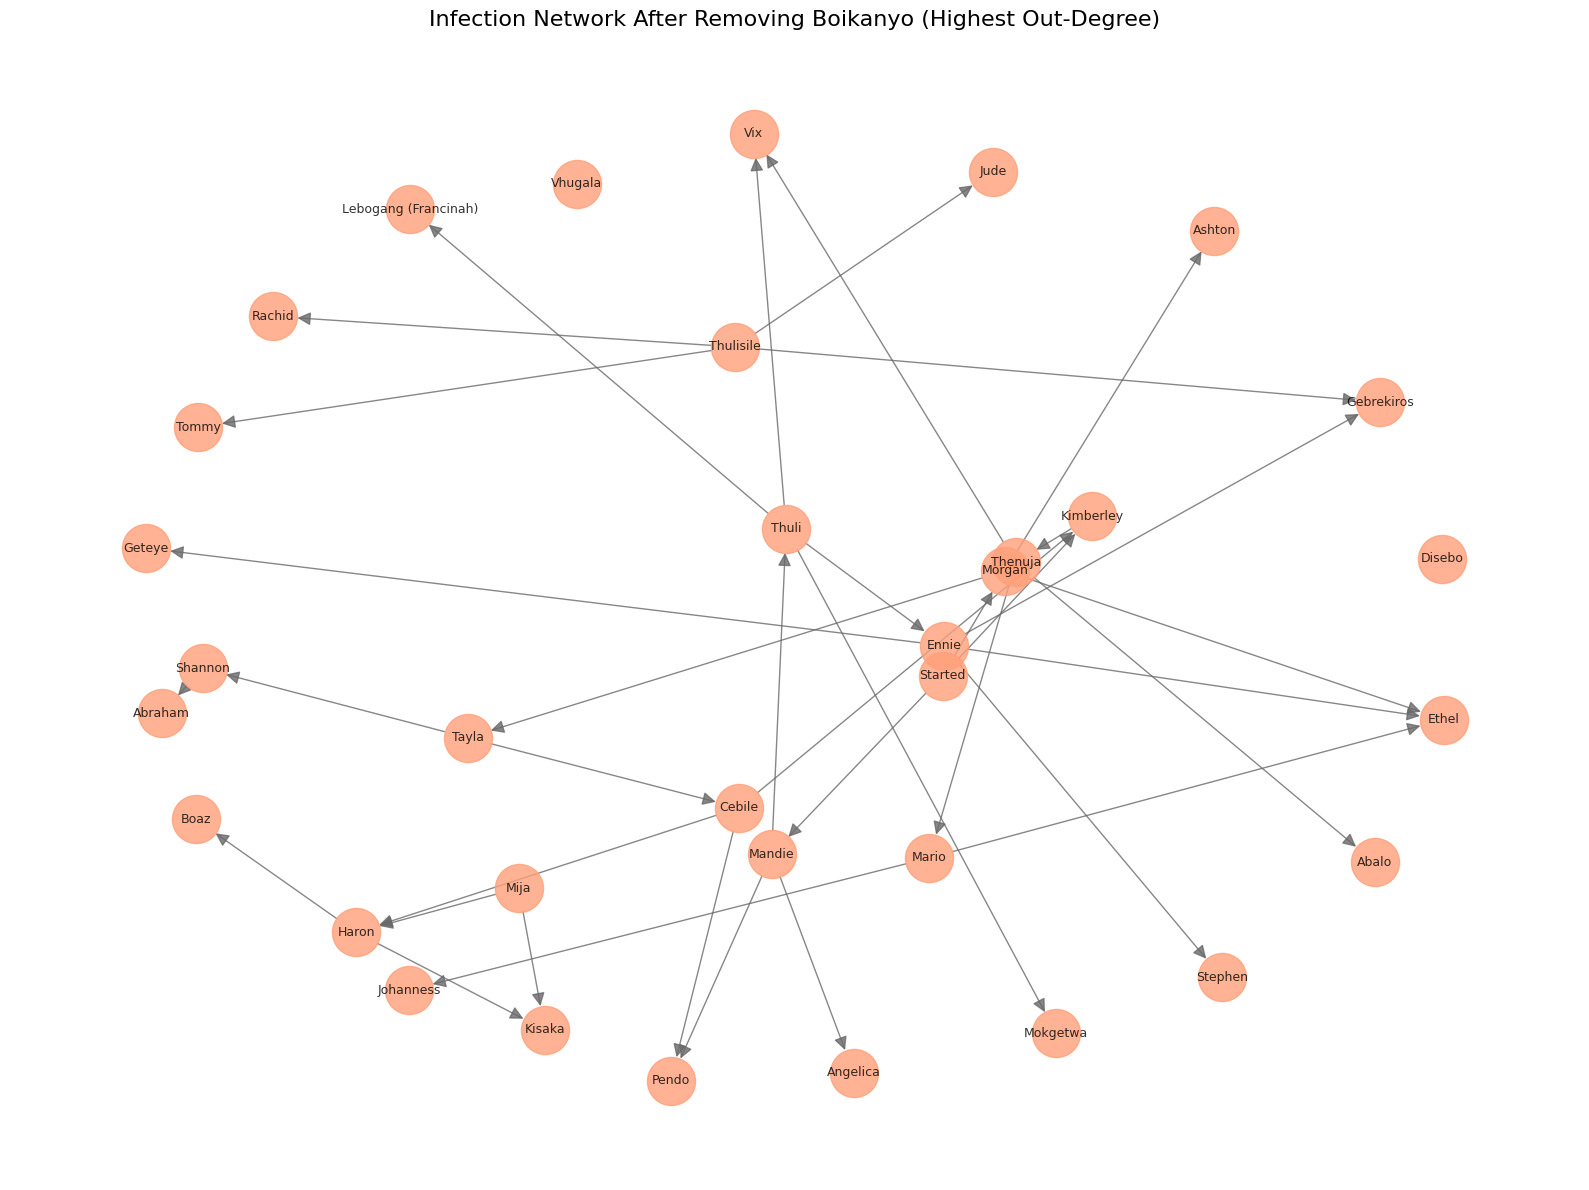

In [155]:
# Identify the node with the highest Out-Degree Centrality in the original graph
top_out_degree_node = out_centrality_series.idxmax()
print(f"Node with highest Out-Degree Centrality: {top_out_degree_node}")

# Create a copy of the original graph to simulate node removal
G_removed_out_degree = G.copy()

# Remove the top out-degree node if it exists
if top_out_degree_node in G_removed_out_degree.nodes():
    G_removed_out_degree.remove_node(top_out_degree_node)
    print(f"Node '{top_out_degree_node}' removed from the graph.")
else:
    print(f"Node '{top_out_degree_node}' not found in the graph.")

# Recalculate Out-Degree Centrality for the modified graph
out_degree_centrality_removed = nx.out_degree_centrality(G_removed_out_degree)
out_centrality_removed_series = pd.Series(out_degree_centrality_removed, name='out_centrality_removed')

print(f"\nTop 5 Nodes by Out-Degree Centrality after removing '{top_out_degree_node}':")
display(out_centrality_removed_series.nlargest(5))

# Visualize the graph after removing the top out-degree node
plt.figure(figsize=(16, 12))

pos_removed_out_degree = nx.spring_layout(G_removed_out_degree, k=0.7, iterations=150)

nx.draw_networkx(
    G_removed_out_degree,
    pos=pos_removed_out_degree,
    with_labels=True,
    node_size=1200,
    node_color='lightsalmon', # Color all remaining nodes uniformly for this initial visualization
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

plt.title(f'Infection Network After Removing {top_out_degree_node} (Highest Out-Degree)', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Simulating Node Removal: Impact of Removing a High Eigenvector Centrality Node

Finally, let's analyze the impact of removing a node with high Eigenvector Centrality. Such a node is connected to many other highly central nodes, making it a significant influencer. Its removal could drastically alter the influence structure of the network.

Node with highest Eigenvector Centrality: Ethel
Node 'Ethel' removed from the graph.

Top 5 Nodes by Eigenvector Centrality after removing 'Ethel':


,eigenvector_centrality_removed
Johanness,0.999837
Vix,0.010415
Mario,0.010415
Abalo,0.010415
Kisaka,0.000196


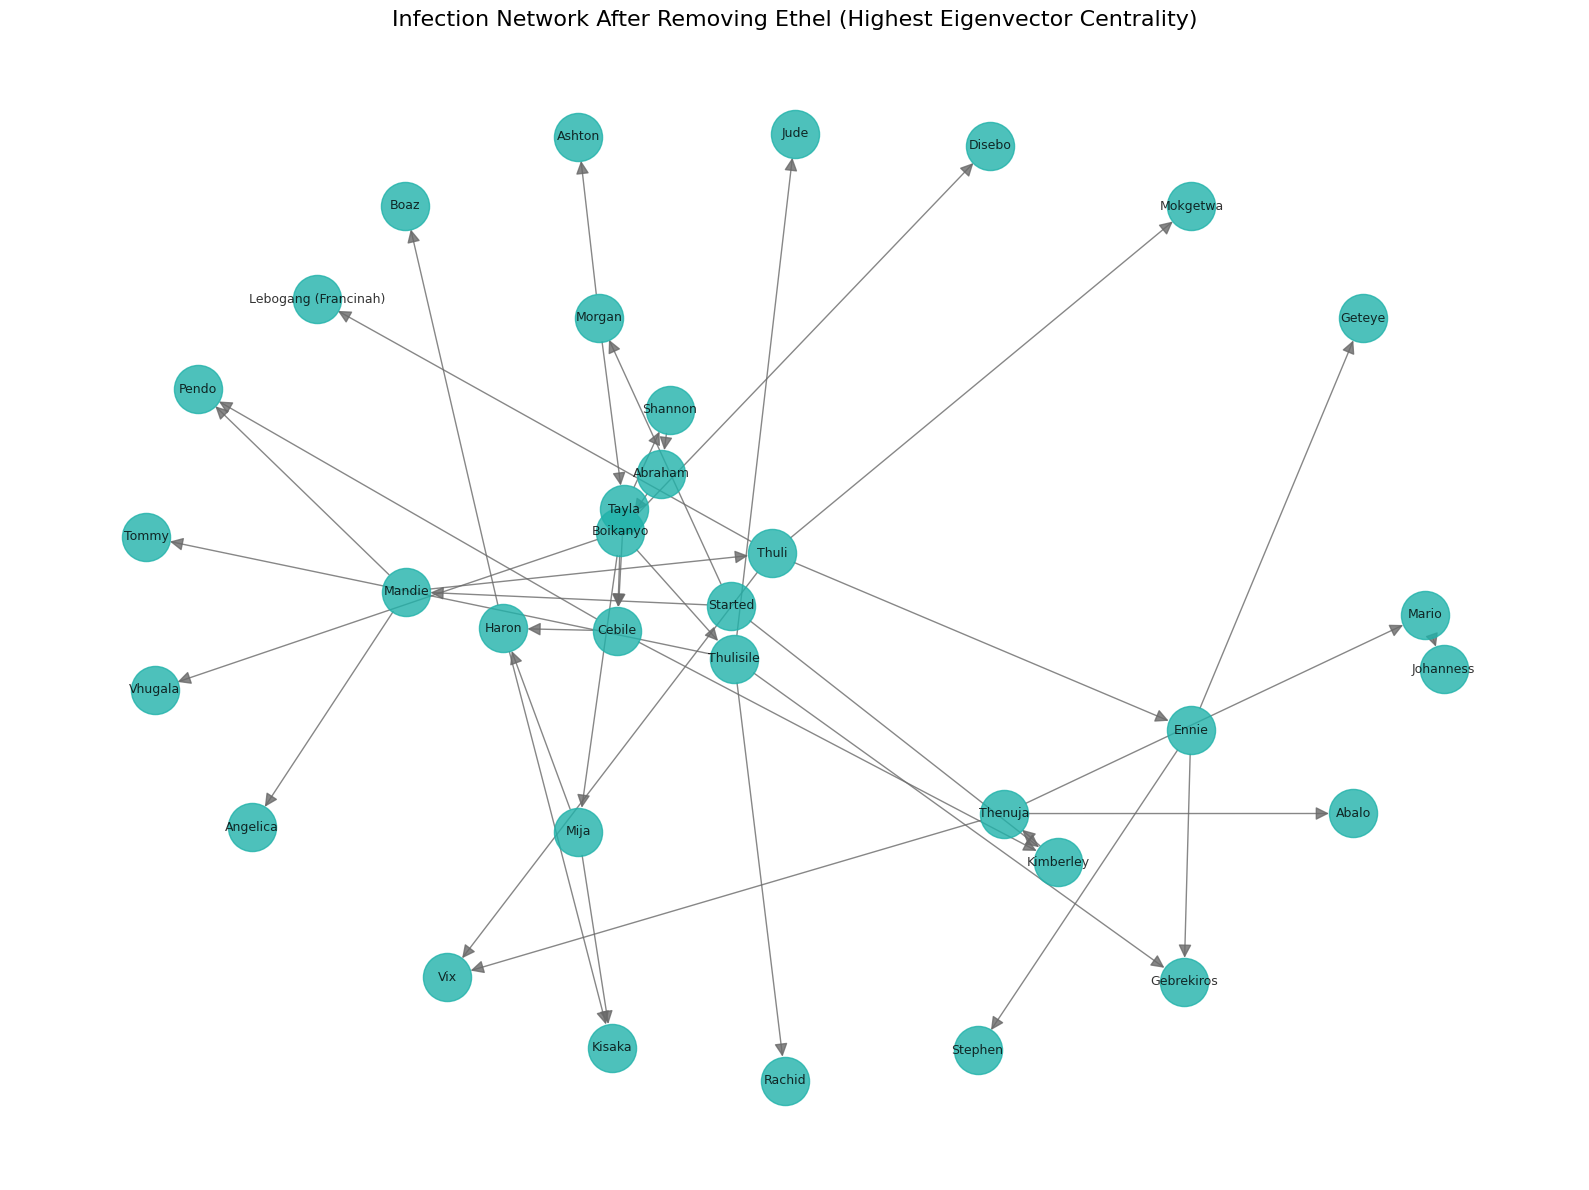

In [175]:
# Identify the node with the highest Eigenvector Centrality in the original graph
top_eigenvector_node = eigenvector_centrality_series.idxmax()
print(f"Node with highest Eigenvector Centrality: {top_eigenvector_node}")

# Create a copy of the original graph to simulate node removal
G_removed_eigenvector = G.copy()

# Remove the top eigenvector node if it exists
if top_eigenvector_node in G_removed_eigenvector.nodes():
    G_removed_eigenvector.remove_node(top_eigenvector_node)
    print(f"Node '{top_eigenvector_node}' removed from the graph.")
else:
    print(f"Node '{top_eigenvector_node}' not found in the graph.")

# Recalculate Eigenvector Centrality for the modified graph
eigenvector_centrality_removed = nx.eigenvector_centrality(G_removed_eigenvector, max_iter=1000)
eigenvector_centrality_removed_series = pd.Series(eigenvector_centrality_removed, name='eigenvector_centrality_removed')

print(f"\nTop 5 Nodes by Eigenvector Centrality after removing '{top_eigenvector_node}':")
display(eigenvector_centrality_removed_series.nlargest(5))

# Visualize the graph after removing the top eigenvector node
plt.figure(figsize=(16, 12))

pos_removed_eigenvector = nx.spring_layout(G_removed_eigenvector, k=0.7, iterations=150)

nx.draw_networkx(
    G_removed_eigenvector,
    pos=pos_removed_eigenvector,
    with_labels=True,
    node_size=1200,
    node_color='lightseagreen', # Color all remaining nodes uniformly for this initial visualization
    font_size=9,
    font_color='black',
    arrowsize=20,
    width=1,
    alpha=0.8,
    edge_color='dimgray'
)

plt.title(f'Infection Network After Removing {top_eigenvector_node} (Highest Eigenvector Centrality)', size=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### Analysis of Removing a High In-Degree Node

Removing a node with high in-degree centrality, which is a major recipient of connections, can have several effects:

*   **Reduced vulnerability:** The network as a whole might become less vulnerable to widespread infection if a key recipient is removed.
*   **Shift in infection patterns:** Other nodes might become relatively more central in terms of receiving infections.
*   **Minimal disruption to sources:** This removal primarily affects those who would infect this node, rather than the infection pathways to other nodes.

Next, let's consider removing a highly central node for Out-Degree Centrality.

### Shortest Path Length

Shortest path length refers to the minimum number of edges that must be traversed to go from one node to another. The **average shortest path length** of a graph is the average of these shortest paths over all possible pairs of nodes. For directed graphs, this is usually computed only for strongly connected graphs or within their strongly connected components.

In [157]:
if nx.is_strongly_connected(G):
    avg_shortest_path_length = nx.average_shortest_path_length(G)
    print(f"Average Shortest Path Length: {avg_shortest_path_length}")
else:
    print("The graph is not strongly connected. Average shortest path length is typically calculated for strongly connected components.")
    print("To calculate it, we would need to find all strongly connected components and then compute the average shortest path length for each component individually.")

The graph is not strongly connected. Average shortest path length is typically calculated for strongly connected components.
To calculate it, we would need to find all strongly connected components and then compute the average shortest path length for each component individually.


### Clustering Coefficient

The clustering coefficient measures the degree to which nodes in a graph tend to cluster together. For a directed graph, the clustering coefficient for a node reflects how complete its neighborhood is. The average clustering coefficient gives an overall indication of the cliquishness of the graph.

In [158]:
# Calculate the average clustering coefficient for the directed graph
average_clustering_coefficient = nx.average_clustering(G)

print(f"Average Clustering Coefficient: {average_clustering_coefficient}")

Average Clustering Coefficient: 0.02142857142857143


### In-Degree Distribution

The in-degree distribution shows how many incoming connections nodes typically have. A high peak at lower values suggests most nodes receive few connections, while a long tail indicates a few nodes are major recipients.

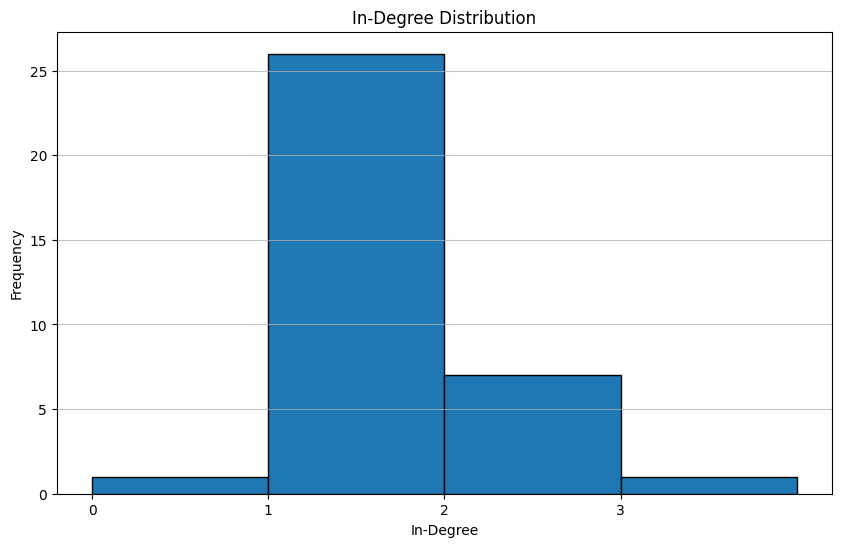

In [159]:
# Get the in-degree sequence
in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)

plt.figure(figsize=(10, 6))
plt.hist(in_degree_sequence, bins=range(min(in_degree_sequence), max(in_degree_sequence) + 2), edgecolor='black')
plt.xlabel("In-Degree")
plt.ylabel("Frequency")
plt.title("In-Degree Distribution")
plt.xticks(range(min(in_degree_sequence), max(in_degree_sequence) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

### Out-Degree Distribution

Similarly, the out-degree distribution illustrates how many outgoing connections nodes typically initiate. This helps identify nodes that act as central broadcasters or sources of information within the network.

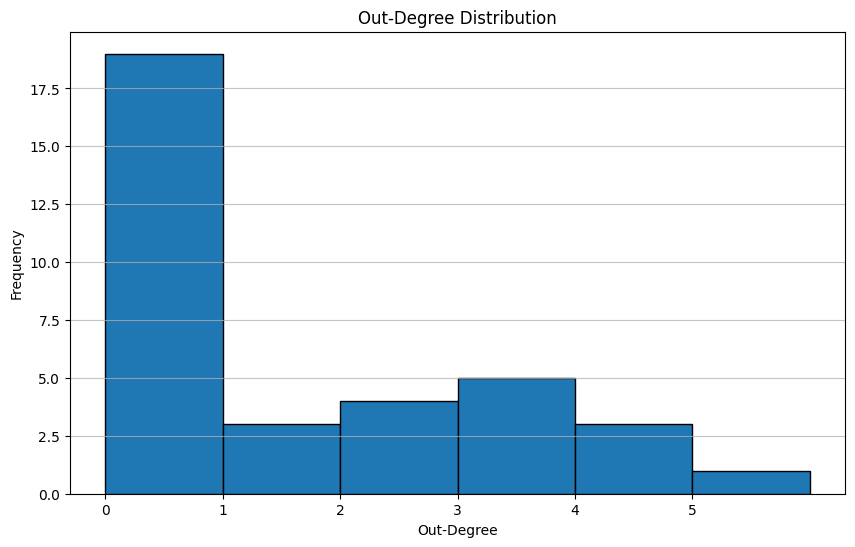

In [160]:
# Get the out-degree sequence
out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)

plt.figure(figsize=(10, 6))
plt.hist(out_degree_sequence, bins=range(min(out_degree_sequence), max(out_degree_sequence) + 2), edgecolor='black')
plt.xlabel("Out-Degree")
plt.ylabel("Frequency")
plt.title("Out-Degree Distribution")
plt.xticks(range(min(out_degree_sequence), max(out_degree_sequence) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()